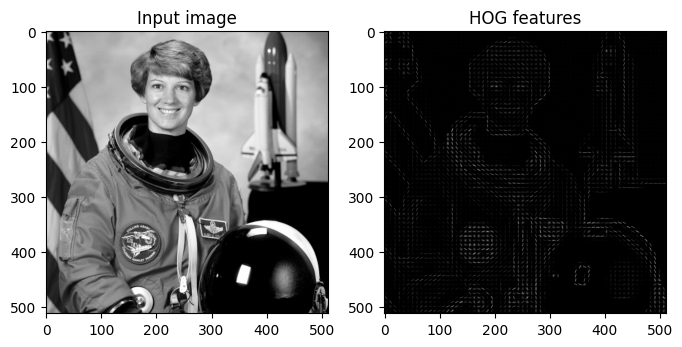

In [4]:
from skimage import color
from skimage.feature import hog
from skimage import data, exposure, io
import matplotlib.pyplot as plt
#pip install scikit-image

# Loading an example image
image = data.astronaut()
image_gray = color.rgb2gray(image) # Converting image to grayscale

# Extract HOG features
features, hog_image = hog(image_gray, orientations=9, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), visualize=True)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Input image')

plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap='gray')
plt.title('HOG features')
plt.show()

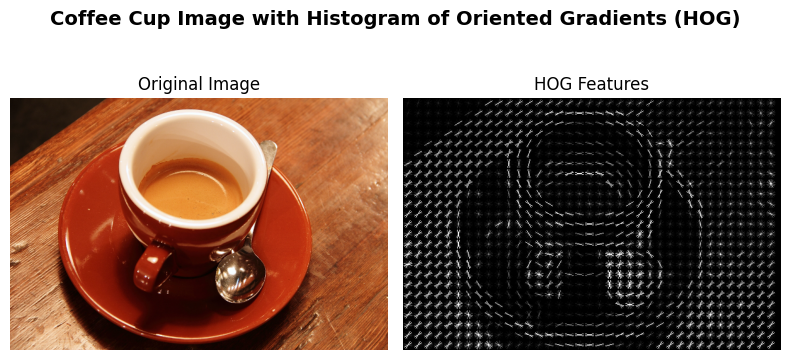

In [5]:
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import data, exposure

# Load the built-in coffee image
image = data.coffee()

# Compute HOG features 
# FIX: Changed multichannel=True to channel_axis=-1 for newer skimage versions
fd, hog_image = hog(image, orientations=8, pixels_per_cell=(16, 16), 
                    cells_per_block=(1, 1), visualize=True, channel_axis=-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4), sharex=True, sharey=True)
fig.suptitle('Coffee Cup Image with Histogram of Oriented Gradients (HOG)', fontsize=14, fontweight='bold')

# Display Original
ax1.imshow(image)
ax1.set_title('Original Image')
ax1.axis('off')

# Rescale histogram for better display
# This makes the faint lines brighter so we can actually see them
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

# Display HOG Features
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('HOG Features')
ax2.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.85) 
plt.show()

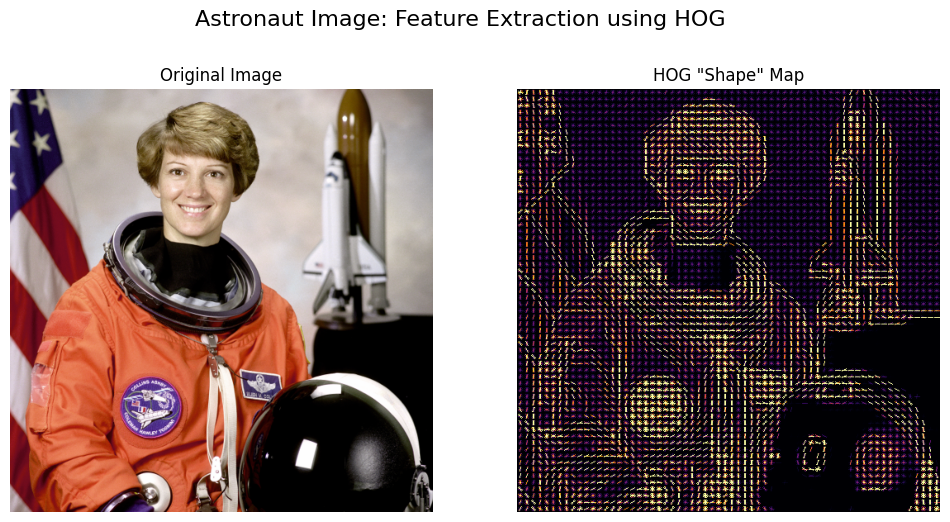

In [6]:
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import data, exposure

# 1. Load the astronaut image (Human/Complex features)
image = data.astronaut()

# 2. Compute HOG features
# We'll use 9 orientations this time (common for human detection)
fd, hog_image = hog(image, orientations=9, pixels_per_cell=(8, 8), 
                    cells_per_block=(2, 2), visualize=True, channel_axis=-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
fig.suptitle('Astronaut Image: Feature Extraction using HOG', fontsize=16)

# Display Original
ax1.imshow(image)
ax1.set_title('Original Image')
ax1.axis('off')

# 3. Rescale for visibility
# HOG values are often small; this "turns up the lights" on the result
hog_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

# Display HOG Features
ax2.imshow(hog_rescaled, cmap='inferno') # Using 'inferno' makes the edges glow!
ax2.set_title('HOG "Shape" Map')
ax2.axis('off')

plt.show()